# M1 — Deep Linear Network Dynamics

Verifying gradient descent against an exact solution.

Full specification: [`docs/m1-deep-linear-dynamics.md`](../docs/m1-deep-linear-dynamics.md)

A two-layer linear network is trained by full-batch gradient descent on a low-rank
target under balanced initialisation - a regime in which the learning dynamics have a
closed-form solution. The trajectory is checked against two separate references:

1. the **exact discrete recursion**, which isolates implementation error;
2. the **continuous closed form**, whose residual is discretisation error and should
   scale as O(η).

## Setup

`float64` throughout: the system is 5×5, so precision is free, and at small η the
fp32 noise floor sits at the same order as the effect being measured.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set the default data type for PyTorch tensors to float64 and set the random seed for reproducibility
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# Define the singular values of the data matrix and other hyperparameters
S = torch.tensor([1.0, 0.62, 0.38, 0.24, 0.15])
N = len(S)
a0 = 1e-6
ETA = 0.01
STEPS = 6000

# Set the default figure size and update the plotting parameters for better visualization
plt.rcParams.update({"figure.dpi": 130, "font.size":9})

## Problem Construction 

$$L(W_1, W_2) = \tfrac{1}{2}\lVert \Sigma - W_2 W_1 \rVert_F^2, \qquad  \Sigma = U S V^\top$$

Balanced aligned initialisation:

$$W_1 = \sqrt{a_0}\, V^\top, \qquad W_2 = \sqrt{a_0}\, U$$

so that $W_2W_1 = a_0 UV^\top$; every mode starts at strength $a_0$ and $W_2^\top W_2 = W_1W_1^\top = a_0 I$

If this is wrong the modes do not decouple: the curves will vaguely look sigmoidal but the closed form will not fit

In [3]:
# Initialise random orthogonal qr factors of gaussian matrices in U and V
U = torch.linalg.qr(torch.randn(N, N))[0]  # Generate a random orthogonal matrix U using QR decomposition
V = torch.linalg.qr(torch.randn(N, N))[0]  # Generate a random orthogonal matrix V using QR decomposition

# Now we build Sigma from U, V, S
Sigma = torch.matmul(U, torch.matmul(torch.diag(S), V.T))  # Construct the data matrix Sigma using U, S, and V

# Now we build W1 and W2 from U, V, a0
W1 = torch.sqrt(torch.tensor(a0)) * V.T
W2 = torch.sqrt(torch.tensor(a0)) * U

# We create an identity matrix of size N for later use in assertions
I = torch.eye(N)  # Create an identity matrix of size N

# Check that W2 @ W1 has the same singular values as Sigma, and that W2.T @ W2 and W1 @ W1.T are scaled identity matrices
# rtol/atol are pinned: the default atol=1e-8 is 1e4x larger than a0 itself, so it would
# accept any a0 within ~1% and never catch a wrong initialisation.
sv0 = torch.linalg.svdvals(W2 @ W1)  # Compute the singular values of the product W2 @ W1
assert torch.allclose(torch.linalg.svdvals(W2 @ W1), torch.full((N,), a0), rtol=1e-12, atol=0.0)
assert torch.allclose(W2.T @ W2, a0 * I)
assert torch.allclose(W1 @ W1.T, a0 * I)


print(f"initial mode strengths : {sv0.numpy()}")
print(f"target spectrum        : {S.numpy()}")
print(f"balance residual       : {((W2.T @ W2) / a0 - I).abs().max():.2e}")



initial mode strengths : [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06]
target spectrum        : [1.   0.62 0.38 0.24 0.15]
balance residual       : 4.44e-16


## Gradient Check
The training loop computes gradient by hand rather than by calling `backward`:

$$\nabla_{W_2} L = E W_1^\top, \qquad \nabla_{W_1} L = W_2^\top E, \qquad E = W_2W_1 - \Sigma$$

Verified against autograd before running 6000 steps of it

In [4]:
# We check the gradients on clones, so that autograd tracking stays on these copies and
# the module-level W1 and W2 are left untouched for the manual training loop below
W1c = W1.clone().requires_grad_(True)
W2c = W2.clone().requires_grad_(True)

loss = 0.5 *torch.linalg.matrix_norm(Sigma - W2c @ W1c) ** 2  # Define the loss function as the squared Frobenius norm of the difference between Sigma and W2 @ W1

loss.backward()  # Compute the gradients of the loss with respect to W1 and W2

E = torch.matmul(W2c, W1c) - Sigma  # Compute the error matrix E as the difference between W2 @ W1 and Sigma

g1 = torch.matmul(W2c.T, E)  # Compute the gradient of W1 as W2.T @ E
g2 = torch.matmul(E, W1c.T)  # Compute the gradient of W2 as E @ W1.T

assert torch.allclose(W1c.grad, g1)  # Assert that the computed gradient of W1 matches g1
assert torch.allclose(W2c.grad, g2)  # Assert that the computed gradient of W2 matches g2

print(f"dL/dW1 max abs diff: {(W1c.grad - g1).abs().max():.2e}")
print(f"dL/dW2 max abs diff: {(W2c.grad - g2).abs().max():.2e}")

dL/dW1 max abs diff: 5.42e-20
dL/dW2 max abs diff: 5.42e-20


## Training

Full-batch gradient descent, manual updates. No `torch.optim`, no `autograd`

Both factors are updated from the **same** $E$. Stepping $W_2$ first and using the updated value to form $\nabla_{W_1}L$ is a different algorithm and will fail Criterion 1

In [5]:
def train(a0=a0, eta=ETA, steps=STEPS, s=S, seed=0):
    """Returns (sv, loss): sv is (steps+1, N), loss is (steps+1,)."""
    torch.manual_seed(seed)
    N = len(s)  # derived from the s that was passed, not read from the global
    U = torch.linalg.qr(torch.randn(N, N))[0]  # Generate a random orthogonal matrix U using QR decomposition
    V = torch.linalg.qr(torch.randn(N, N))[0]  # Generate a random orthogonal matrix V using QR decomposition

    # Now we build Sigma from U, V, s
    Sigma = torch.matmul(U, torch.matmul(torch.diag(s), V.T))  # Construct the data matrix Sigma using U, s, and V

    # Now we build W1 and W2 from U, V, a0
    W1 = torch.sqrt(torch.tensor(a0)) * V.T
    W2 = torch.sqrt(torch.tensor(a0)) * U
    sv, loss = [], []

    for k in range(steps + 1):
        P = W2 @ W1
        E = P - Sigma
        sv.append(torch.linalg.svdvals(P))
        loss.append(0.5 * (E**2).sum())
        g1, g2 = W2.T @ E, E @ W1.T
        W1 = W1 - eta * g1
        W2 = W2 - eta * g2
    return torch.stack(sv), torch.tensor(loss)

sv, loss = train()

print(f"final mode strengths : {sv[-1].numpy()}")
print(f"first loss : {loss[0].numpy():.2e}")
print(f"final loss : {loss[-1].numpy():.2e}")

final mode strengths : [1.         0.62       0.38       0.23999998 0.14965817]
first loss : 8.04e-01
final loss : 5.84e-08


## Reference trajectories

**Continuous** — solution of the gradient flow $\dot a_i = 2\eta a_i(s_i - a_i)$:

$$a_i(k) = \frac{s_i}{1 + \left(\frac{s_i}{a_0} - 1\right)e^{-2\eta s_i k}}$$

**Discrete** — exactly what gradient descent does under balanced init:

$$a_{k+1} = a_k\big(1 + \eta(s - a_k)\big)^2$$

The second is the reference for *implementation*; the first is the reference for
*approximation*.

In [6]:
def closed_form(a0 = a0, eta = ETA, steps = STEPS, s = S):
    """Gradient-flow solution, eq. (1). Shape (steps+1, len(s))."""
    k = torch.arange(steps + 1).reshape(-1, 1)
    return s /(1+(s/a0 - 1)* torch.exp(-2*eta*s*k))

def discrete_recursion(a0 = a0, eta = ETA, steps = STEPS, s = S):
    """Exact gradient-descent map, eq. (3). Shape (steps+1, len(s))."""
    a = torch.full_like(s, a0)
    out = []
    for _ in range (steps + 1):
        out.append(a)
        a = a*(1+eta*(s-a))**2
    return torch.stack(out)

ana = closed_form()
dis = discrete_recursion()

print(f"shapes      : {sv.shape}, {ana.shape}, {dis.shape}")
print(f"ana[0]      : {ana[0].numpy()}")
print(f"ana[-1]     : {ana[-1].numpy()}")
print(f"|sv - dis|  : {((sv - dis).abs() / dis).max():.2e}")
print(f"|sv - ana|  : {((sv - ana).abs() / ana).max():.2e}")


shapes      : torch.Size([6001, 5]), torch.Size([6001, 5]), torch.Size([6001, 5])
ana[0]      : [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06]
ana[-1]     : [1.         0.62       0.38       0.23999998 0.14965811]
|sv - dis|  : 2.39e-12
|sv - ana|  : 4.97e-02


## Criterion 1 - Implementation

Against the exact recursion, agreement should be at machine precision.

**Pass:** max relative error < `1e-10`. Reference implementation measures 3–6e-12
across seeds.

A value near `1e-3` indicates a defect — most likely an unbalanced initialisation, or
$W_1$ updated using the already-updated $W_2$.

In [7]:
err = ((sv - dis).abs() / dis).max()
print(f"max relative error vs discrete recursion: {err:.2e}")
assert err < 1e-10, "implementation check failed"

max relative error vs discrete recursion: 2.39e-12


## Figure 1 — mode strengths

Modes are learned sequentially, strongest first: $k_i = \ln(s_i/a_0)/(2\eta s_i) \propto 1/s_i$.

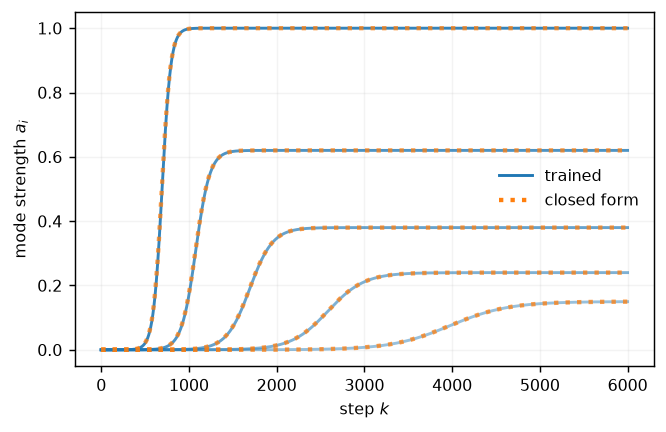

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
k = np.arange(STEPS + 1)
for i in range(N):
    ax.plot(k, sv[:, i], lw=1.6, color="C0", alpha=0.9 - 0.11 * i)
    ax.plot(k, ana[:, i], lw=2.4, color="C1", ls=":", alpha=0.75)
ax.plot([], [], color="C0", lw=1.6, label="trained")
ax.plot([], [], color="C1", lw=2.4, ls=":", label="closed form")
ax.set_xlabel("step $k$"); ax.set_ylabel("mode strength $a_i$")
ax.legend(frameon=False); ax.grid(alpha=0.15)
fig.tight_layout(); fig.savefig("../figures/m1_modes.png", dpi=200)

## Figure 2 - The loss staircase

Each mode contributes $\tfrac{1}{2}(s_i - a_i)^2$ to the loss, so the loss falls in
five steps rather than smoothly — one per mode, in order of $s_i$.

The steps are only resolved because $a_0 = 10^{-6}$. At $a_0 = 10^{-3}$ consecutive
transitions overlap (gap/width $= 0.63$) and the same run produces a smooth decay with
no visible structure.

Log scale on the right: the staircase is the same object, but the plateaus between
transitions are far more legible.

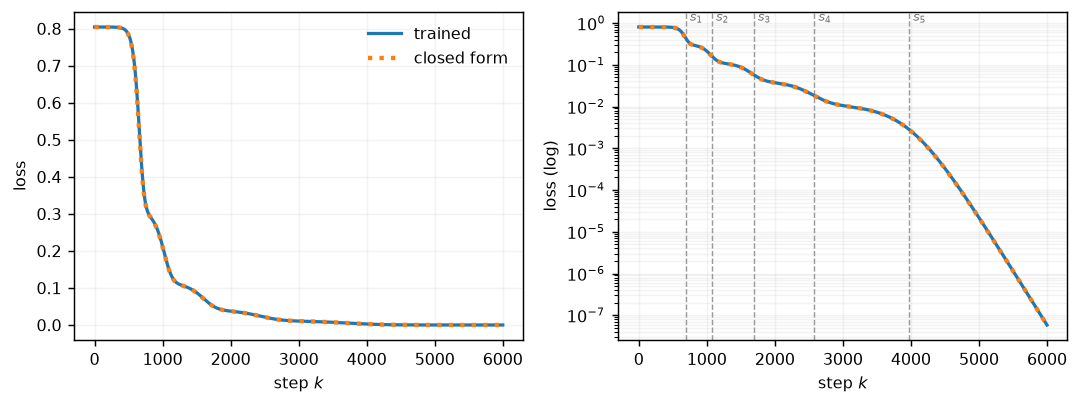

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))
k = np.arange(STEPS + 1)

ana_loss = 0.5 * ((S - ana) ** 2).sum(dim=1)

for ax, logy in zip(axes, [False, True]):
    ax.plot(k, loss, lw=1.8, color="C0", label="trained")
    ax.plot(k, ana_loss, lw=2.4, ls=":", color="C1", label="closed form")
    if logy:
        ax.set_yscale("log")
        ax.set_ylabel("loss (log)")
    else:
        ax.set_ylabel("loss")
    ax.set_xlabel("step $k$")
    ax.grid(alpha=0.15, which="both")

# mark the predicted transition points on the log panel
k_pred = torch.log(S / a0) / (2 * ETA * S)
for i, kp in enumerate(k_pred):
    axes[1].axvline(kp, color="0.6", lw=0.8, ls="--", zorder=0)
    axes[1].text(kp, axes[1].get_ylim()[1], f" $s_{i+1}$",
                 va="top", ha="left", fontsize=7, color="0.45")

axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig("../figures/m1_loss.png", dpi=200)

## Criterion 2 - discretisation order

The closed form solves the gradient *flow*; the loop runs gradient *descent*, which is forward Euler on that flow. The residual is therefore $O(\eta)$, not a bug

**Pass:** log–log slope of max error against η equal to 1.0 within a few percent.
Reference: 0.968.

In [10]:
SWEEP = [(0.05, 1200), (0.02, 3000), (0.01, 6000),
         (0.005, 12000), (0.002, 30000), (0.001, 60000)]

etas, errs = [], []

for eta, steps in SWEEP:
    # the loss trajectory is discarded here: binding it to `loss` would clobber the
    # principal run that Figure 2 plots
    sv_e, _ = train(eta=eta, steps=steps)
    ana_e =  closed_form(eta=eta, steps=steps)
    err = ((sv_e - ana_e).abs() / ana_e).max().item()
    errs.append(err)
    etas.append(eta)
    print(f"eta={eta:<6} steps={steps:<6} max rel err={err:.2e}")

slope = np.polyfit(np.log(etas), np.log(errs), 1)[0]
print(f"\nfitted log-log slope: {slope:.3f} (expect 1.0)")

eta=0.05   steps=1200   max rel err=2.22e-01


eta=0.02   steps=3000   max rel err=9.67e-02


eta=0.01   steps=6000   max rel err=4.97e-02


eta=0.005  steps=12000  max rel err=2.52e-02


eta=0.002  steps=30000  max rel err=1.02e-02


eta=0.001  steps=60000  max rel err=5.11e-03

fitted log-log slope: 0.968 (expect 1.0)


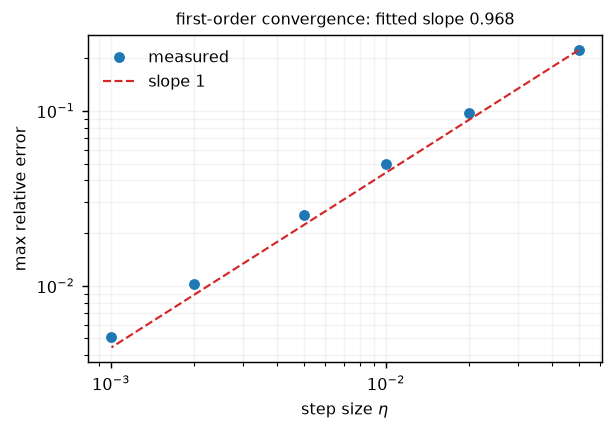

In [11]:
fig, ax = plt.subplots(figsize=(4.8, 3.4))
ax.loglog(etas, errs, "o", ms=5, color="C0", label="measured")

ref = np.array(etas) * errs[0] / etas[0]
ax.loglog(etas, ref, "--", lw=1.2, color="C3", label="slope 1")

ax.set_xlabel(r"step size $\eta$")
ax.set_ylabel("max relative error")
ax.set_title(f"first-order convergence: fitted slope {slope:.3f}", fontsize=9)
ax.legend(frameon=False)
ax.grid(alpha=0.15, which="both")
fig.tight_layout()
fig.savefig("../figures/m1_convergence.png", dpi=200)

## Learning times

Equation (2) predicts the step at which each mode reaches half its target strength:

$$k_i = \frac{\ln(s_i/a_0)}{2\eta s_i} \;\propto\; \frac{1}{s_i}$$

This is the robust comparison. Pointwise error is harsh mid-transition — a small
timing offset registers as a large difference in value — but the crossing times
themselves are stable.

The percentage is the wrong way to read this table. What the run actually shows is a
near-constant **lag**: the observed crossing sits about 3.2 steps after the predicted one
at every mode, and stays there across a 50× range of η. The percentage varies across
modes only because $k_i \propto 1/s_i$, and falls with η only because $k_i \propto 1/\eta$
— in both cases it is the denominator moving, not the discrepancy.

Rescaling time by $\ln(1+\eta s_i)/(\eta s_i)$ in the logistic solution gives a lag of
$\ln(s_i/a_0)/4$ to leading order, independent of η — the `lag pred` column below.

**Caveat.** `argmax` on the boolean crossing quantises to whole steps, which biases the
observed lag low by up to one step, so this is order-of-magnitude agreement rather than a
tight test. Interpolating the crossing would sharpen it — not done here.

The percentage column stays because the pass criterion is defined on its maximum.

In [12]:
k_pred = torch.log(S / a0) / (2 * ETA * S)
k_obs  = torch.tensor([(sv[:, i] > S[i] / 2).to(torch.int).argmax() for i in range(N)])

lag      = k_obs - k_pred         # observed minus predicted, in steps - the eta-independent quantity
lag_pred = torch.log(S / a0) / 4  # leading-order prediction of that lag, independent of eta
pct      = (k_obs - k_pred).abs() / k_pred * 100

print(f"{'mode':>5} {'s_i':>7} {'predicted':>11} {'observed':>10} {'lag':>7} {'lag pred':>9} {'error':>8}")
for i in range(N):
    print(f"{i+1:>5} {S[i]:>7.2f} {k_pred[i]:>11.1f} {k_obs[i]:>10d} "
          f"{lag[i]:>7.1f} {lag_pred[i]:>9.2f} {pct[i]:>7.2f}%")
print(f"\nmean lag: {lag.mean():.1f} steps   max error: {pct.max():.2f}%")
assert pct.max() < 1.0, "learning times do not match prediction"

 mode     s_i   predicted   observed     lag  lag pred    error
    1    1.00       690.8        694     3.2      3.45    0.47%
    2    0.62      1075.6       1079     3.4      3.33    0.32%
    3    0.38      1690.5       1694     3.5      3.21    0.21%
    4    0.24      2580.9       2584     3.1      3.10    0.12%
    5    0.15      3972.8       3976     3.2      2.98    0.08%

mean lag: 3.3 steps   max error: 0.47%


## Summary

| Check | Criterion | Result |
|---|---|---|
| **C1** — vs exact recursion (3) | < 1e-10 | 2.39e-12 |
| **C2** — convergence slope | 1.0 ± few % | 0.968 |
| Learning times | < 1% | 0.47% |

Four deliverables produced:

1. `figures/m1_modes.png` — sequential learning, strongest mode first
2. `figures/m1_loss.png` — the staircase, one step per mode
3. `figures/m1_convergence.png` — first-order convergence in η
4. Learning-time table above — $k_i \propto 1/s_i$ verified

### What this establishes

The training loop implements gradient descent exactly: agreement with the discrete
recursion is at machine precision. The residual against the continuous closed form is
therefore not implementation error but discretisation error, and it is first-order in
the step size — gradient descent is forward Euler on gradient flow, measured rather
than asserted.